# SUPR — Debug Playground

Step-through notebook for the downloaded SUPR/SUPR-Foot model files. Each cell mirrors one stage of the tiny SUPR pipeline: environment, imports, model dictionary inspection, template mesh creation, official forward pass, and mesh export.


## 0 — Environment & cache setup


In [1]:
import os

cache_root = "/data/abelde"
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

os.environ["PIP_CACHE_DIR"]  = os.path.join(cache_root, ".cache", "pip")
os.environ["TORCH_HOME"]     = os.path.join(cache_root, ".cache", "torch")
os.environ["HF_HOME"]        = os.path.join(cache_root, ".cache", "huggingface")

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))


CUDA_VISIBLE_DEVICES: 5


## 1 — Imports & paths


In [2]:
import os, sys, time
from pathlib import Path
from collections import Counter, defaultdict, deque

import numpy as np

repo_root = "/data/abelde/projects/active/Shell_Gaussian/baselines/SUPR"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)

print("Warming up torch...")
t0 = time.time()
import torch
print(f"torch imported in {time.time() - t0:.1f}s  |  version: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Logical cuda:0 maps to physical GPU:", os.environ.get("CUDA_VISIBLE_DEVICES", "all visible GPUs"))

from supr.pytorch.supr import SUPR

print("All imports OK")


Warming up torch...
torch imported in 0.8s  |  version: 1.13.1  |  CUDA: True
GPU: NVIDIA A100-SXM4-80GB
Logical cuda:0 maps to physical GPU: 5
All imports OK


## 2 — Model files

The downloaded SUPR files live in `data/`. For shoe work, start with the right-foot model. The full neutral model is useful as reference but much larger.


In [3]:
data_dir = Path(repo_root) / "data"
right_foot_model_path = data_dir / "supr_male_right_foot.npy"
neutral_model_path = data_dir / "supr_neutral.npy"

for path in [right_foot_model_path, neutral_model_path]:
    print(f"{path.name:28s} exists={path.exists()} size={path.stat().st_size / 1024**2:.2f} MB")


supr_male_right_foot.npy     exists=True size=1.50 MB
supr_neutral.npy             exists=True size=228.13 MB


## 3 — Inspect model dictionaries


In [4]:
def describe_model(path):
    model = np.load(path, allow_pickle=True, encoding="latin1")[()]
    print(f"FILE: {path.name}")
    print(f"keys ({len(model)}): {sorted(model.keys())}")
    for key in sorted(model.keys()):
        value = model[key]
        if hasattr(value, "shape"):
            print(f"  {key:14s} shape={str(value.shape):18s} dtype={value.dtype}")
        else:
            print(f"  {key:14s} type={type(value).__name__} value={value!r}")
    print()
    return model

right_foot_model = describe_model(right_foot_model_path)
neutral_model = describe_model(neutral_model_path)


FILE: supr_male_right_foot.npy
keys (8): ['J', 'J_regressor', 'f', 'kintree_table', 'posedirs', 'shapedirs', 'v_template', 'weights']
  J              shape=(13, 3)            dtype=float64
  J_regressor    shape=(39, 799)          dtype=float64
  f              shape=(515, 3)           dtype=uint32
  kintree_table  shape=(2, 13)            dtype=int64
  posedirs       shape=(266, 3, 52)       dtype=float64
  shapedirs      shape=(266, 3, 300)      dtype=float32
  v_template     shape=(266, 3)           dtype=float32
  weights        shape=(266, 13)          dtype=float64

FILE: supr_neutral.npy
keys (10): ['J', 'J_regressor', 'bs_style', 'bs_type', 'f', 'kintree_table', 'posedirs', 'shapedirs', 'v_template', 'weights']
  J              shape=(75, 3)            dtype=float64
  J_regressor    shape=(225, 31426)       dtype=float64
  bs_style       type=str value='lbs'
  bs_type        type=str value='lrotmin'
  f              shape=(20908, 3)         dtype=uint32
  kintree_table  shape=

## 4 — Template mesh inspection

`v_template` and `f` are already enough to make a neutral mesh. This is the simplest starting point for a foot SDF.


In [5]:
def mesh_health(vertices, faces):
    vertices = np.asarray(vertices)
    faces = np.asarray(faces, dtype=np.int64)
    print(f"vertices/faces: {vertices.shape[0]} / {faces.shape[0]}")
    print(f"bounds min:     {vertices.min(axis=0)}")
    print(f"bounds max:     {vertices.max(axis=0)}")
    print(f"extents:        {np.ptp(vertices, axis=0)}")
    print(f"face range:     [{faces.min()}, {faces.max()}]")
    print(f"invalid faces:  {int(((faces < 0) | (faces >= len(vertices))).any(axis=1).sum())}")
    print(f"degenerate:     {int((np.diff(np.sort(faces, axis=1), axis=1) == 0).any(axis=1).sum())}")

    edge_counts = Counter()
    adjacency = defaultdict(set)
    for tri in faces:
        a, b, c = map(int, tri)
        for u, v in ((a, b), (b, c), (c, a)):
            edge = tuple(sorted((u, v)))
            edge_counts[edge] += 1
            adjacency[u].add(v)
            adjacency[v].add(u)

    boundary_edges = sum(1 for count in edge_counts.values() if count == 1)
    nonmanifold_edges = sum(1 for count in edge_counts.values() if count > 2)
    print(f"boundary edges: {boundary_edges}")
    print(f"nonmanifold:    {nonmanifold_edges}")

    unvisited = set(range(len(vertices)))
    components = []
    while unvisited:
        start = unvisited.pop()
        queue = deque([start])
        size = 1
        while queue:
            u = queue.popleft()
            for v in adjacency[u]:
                if v in unvisited:
                    unvisited.remove(v)
                    queue.append(v)
                    size += 1
        components.append(size)
    print(f"components:     {sorted(components, reverse=True)[:8]}")

print("Right foot template")
print("-" * 40)
mesh_health(right_foot_model["v_template"], right_foot_model["f"])

print()
print("Full neutral template")
print("-" * 40)
mesh_health(neutral_model["v_template"], neutral_model["f"])


Right foot template
----------------------------------------
vertices/faces: 266 / 515
bounds min:     [-0.16143256 -1.3569797  -0.11568644]
bounds max:     [-0.05844138 -1.2518517   0.15629017]
extents:        [0.10299118 0.10512805 0.27197662]
face range:     [0, 265]
invalid faces:  0
degenerate:     0
boundary edges: 15
nonmanifold:    0
components:     [266]

Full neutral template
----------------------------------------
vertices/faces: 10475 / 20908
bounds min:     [-0.872039   -1.298006   -0.15121497]
bounds max:     [0.87185335 0.42185217 0.14841603]
extents:        [1.7438924 1.7198582 0.299631 ]
face range:     [0, 10474]
invalid faces:  0
degenerate:     0


boundary edges: 32
nonmanifold:    0
components:     [9383, 546, 546]


## 5 — Load official SUPR model


In [6]:
num_betas = 100
batch_size = 1

supr_foot = SUPR(str(right_foot_model_path), num_betas=num_betas)
supr_foot.display_info()

print("faces:", supr_foot.f.shape)


Kinematic Tree: Un-Constrained
Number of Pose Parameters: 39
Number of Joints: 13
Number of Vertices:266
faces: (515, 3)


## 5.1 — What SUPR-Foot is doing

Think of SUPR-Foot as a small function:

```text
foot_mesh = SUPR_Foot(pose, betas, trans)
```

It starts from a neutral template foot and then applies three kinds of changes:

- `betas`: change the person's foot shape/size/proportions.
- `pose`: rotates the foot joints, so the ankle/toes can bend.
- `trans`: moves the entire already-shaped and already-posed foot in 3D space.

The important order is:

```text
template foot -> shape with betas -> bend with pose -> move with trans
```

In this notebook section, I can change one thing at a time and visualize what it does.


neutral foot
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]


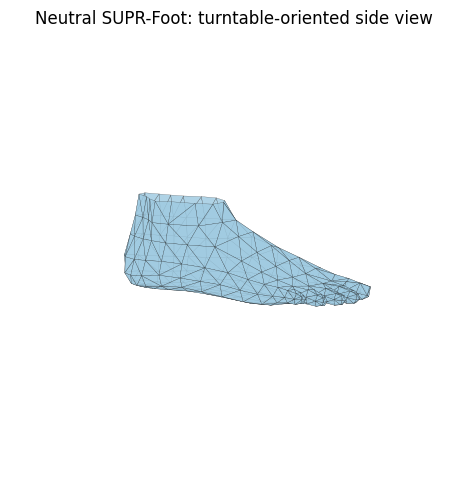

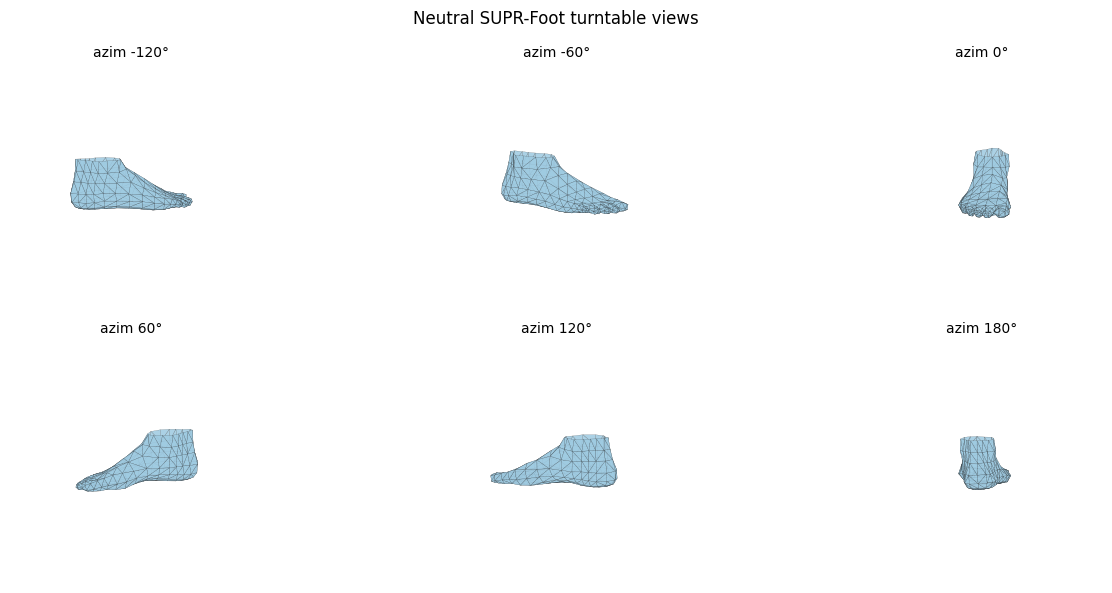

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

foot_faces = np.asarray(supr_foot.f, dtype=np.int64)

# SUPR coordinates are raw model coordinates: x=side, y=body/up-down, z=foot length.
# Matplotlib 3D treats z as the vertical plotting axis, so for visualization we remap:
# plot x <- SUPR z (heel-to-toe length), plot y <- SUPR x (left-right width), plot z <- SUPR y (height).
def to_turntable_coords(points):
    points = np.asarray(points)
    return points[..., [2, 0, 1]]

def zeros_pose():
    return torch.zeros((1, supr_foot.num_pose), dtype=torch.float32, device="cuda")

def zeros_betas():
    return torch.zeros((1, num_betas), dtype=torch.float32, device="cuda")

def zeros_trans():
    return torch.zeros((1, 3), dtype=torch.float32, device="cuda")

def run_supr_foot(pose=None, betas=None, trans=None):
    """Return vertices and transformed joints as NumPy arrays."""
    pose = zeros_pose() if pose is None else pose
    betas = zeros_betas() if betas is None else betas
    trans = zeros_trans() if trans is None else trans
    with torch.no_grad():
        out = supr_foot.forward(pose, betas, trans)
    verts_np = out[0].detach().cpu().numpy()
    joints_np = out.J_transformed[0].detach().cpu().numpy()
    return verts_np, joints_np

def bbox_report(vertices, label="mesh"):
    vertices = np.asarray(vertices)
    mn = vertices.min(axis=0)
    mx = vertices.max(axis=0)
    ext = mx - mn
    print(f"{label}")
    print(f"  raw SUPR min xyz: {mn}")
    print(f"  raw SUPR max xyz: {mx}")
    print(f"  raw SUPR size xyz: {ext}")
    print(f"  raw SUPR center:  {(mn + mx) / 2}")
    return mn, mx, ext

def set_axes_equal(ax, vertices_list):
    all_vertices = np.concatenate([np.asarray(v).reshape(-1, 3) for v in vertices_list], axis=0)
    mn = all_vertices.min(axis=0)
    mx = all_vertices.max(axis=0)
    center = (mn + mx) / 2
    radius = max((mx - mn).max() / 2, 1e-6)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
        ax.set_proj_type("ortho")
    except Exception:
        pass

def style_turntable_axis(ax, show_axes=False):
    if show_axes:
        ax.set_xlabel("SUPR z / foot length")
        ax.set_ylabel("SUPR x / foot width")
        ax.set_zlabel("SUPR y / height")
        ax.grid(False)
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            try:
                axis.pane.fill = False
                axis.pane.set_edgecolor("#dddddd")
            except Exception:
                pass
    else:
        ax.set_axis_off()

def plot_foot(
    vertices,
    joints=None,
    title="SUPR foot",
    color="#9ecae1",
    elev=8,
    azim=-70,
    faces=None,
    show_axes=False,
    show_joints=False,
    label_joints=False,
):
    raw_vertices = np.asarray(vertices)
    vertices_plot = to_turntable_coords(raw_vertices)
    faces = foot_faces if faces is None else np.asarray(faces, dtype=np.int64)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")
    poly = Poly3DCollection(vertices_plot[faces], alpha=0.82, linewidths=0.18)
    poly.set_facecolor(color)
    poly.set_edgecolor("#222222")
    ax.add_collection3d(poly)

    plot_points = [vertices_plot]
    if joints is not None and show_joints:
        joints_plot = to_turntable_coords(joints)
        ax.scatter(joints_plot[:, 0], joints_plot[:, 1], joints_plot[:, 2], c="red", s=18, depthshade=False)
        plot_points.append(joints_plot)
        if label_joints:
            for idx, pnt in enumerate(joints_plot):
                ax.text(pnt[0], pnt[1], pnt[2], str(idx), color="darkred", fontsize=8)

    set_axes_equal(ax, plot_points)
    ax.view_init(elev=elev, azim=azim)
    style_turntable_axis(ax, show_axes=show_axes)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_compare(
    reference_vertices,
    changed_vertices,
    title="comparison",
    changed_label="changed",
    faces=None,
    elev=8,
    azim=-70,
    show_axes=False,
):
    reference_plot = to_turntable_coords(reference_vertices)
    changed_plot = to_turntable_coords(changed_vertices)
    faces = foot_faces if faces is None else np.asarray(faces, dtype=np.int64)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")

    ref_poly = Poly3DCollection(reference_plot[faces], alpha=0.16, linewidths=0.08)
    ref_poly.set_facecolor("#bbbbbb")
    ref_poly.set_edgecolor("#555555")
    ax.add_collection3d(ref_poly)

    changed_poly = Poly3DCollection(changed_plot[faces], alpha=0.78, linewidths=0.16)
    changed_poly.set_facecolor("#fdae6b")
    changed_poly.set_edgecolor("#222222")
    ax.add_collection3d(changed_poly)

    set_axes_equal(ax, [reference_plot, changed_plot])
    ax.view_init(elev=elev, azim=azim)
    style_turntable_axis(ax, show_axes=show_axes)
    ax.set_title(f"gray = neutral, orange = {changed_label}\n{title}")
    plt.tight_layout()
    plt.show()

def plot_turntable(
    vertices,
    title="turntable view",
    faces=None,
    elev=8,
    angles=(-120, -60, 0, 60, 120, 180),
    color="#9ecae1",
):
    vertices_plot = to_turntable_coords(vertices)
    faces = foot_faces if faces is None else np.asarray(faces, dtype=np.int64)

    fig = plt.figure(figsize=(14, 6))
    for i, azim in enumerate(angles, start=1):
        ax = fig.add_subplot(2, 3, i, projection="3d")
        poly = Poly3DCollection(vertices_plot[faces], alpha=0.86, linewidths=0.12)
        poly.set_facecolor(color)
        poly.set_edgecolor("#222222")
        ax.add_collection3d(poly)
        set_axes_equal(ax, [vertices_plot])
        ax.view_init(elev=elev, azim=azim)
        style_turntable_axis(ax, show_axes=False)
        ax.set_title(f"azim {azim}°", fontsize=10)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

neutral_vertices, neutral_joints = run_supr_foot()
bbox_report(neutral_vertices, "neutral foot")
plot_foot(neutral_vertices, title="Neutral SUPR-Foot: turntable-oriented side view")
plot_turntable(neutral_vertices, title="Neutral SUPR-Foot turntable views")


## 5.2 — `betas`: shape and size controls

`betas` are the part of SUPR that changes **what kind of foot/person** the model represents.

They are not direct labels like "US size 9", "wide toe box", or "high arch". A beta is more like a learned shape knob. SUPR learned these knobs from training shapes, so moving one beta changes the mesh along one learned direction. Sometimes that direction looks like overall foot size. Sometimes it changes width, height, arch/toe proportions, or a mix of all of those.

A useful mental model:

```text
same neutral foot
+ beta changes
= a different plausible foot shape
```

For our shoe project, betas are useful because they let us make a family of plausible feet, not just one fixed foot. But to get a true shoe-size slider later, I probably need to fit/search betas so the generated foot matches target measurements such as length, width, and maybe instep height.

Important: positive beta does not always mean "bigger". It only means "move in the positive direction of this learned shape mode." That is why the scan below is useful: it tells me which beta directions actually change length/width/height the most in this downloaded model.


neutral
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]
beta[0] = 2.0
  raw SUPR min xyz: [-0.16498734 -1.3593317  -0.12946963]
  raw SUPR max xyz: [-0.05686719 -1.2439646   0.16617988]
  raw SUPR size xyz: [0.10812015 0.11536717 0.29564953]
  raw SUPR center:  [-0.11092727 -1.3016481   0.01835512]
mean vertex displacement: 0.007880372
max  vertex displacement: 0.014732387


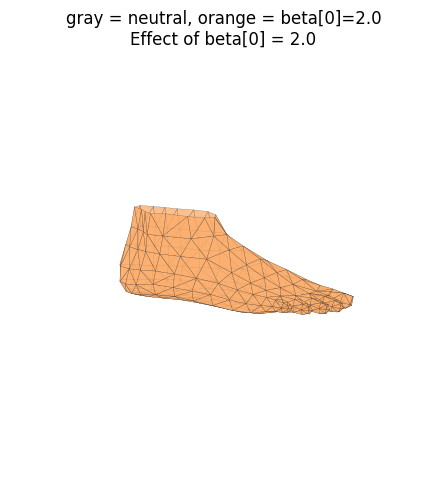

In [8]:
# Change these numbers and re-run this cell.
beta_index = 0
beta_value = 2.0

beta_probe = zeros_betas()
beta_probe[0, beta_index] = beta_value

beta_vertices, beta_joints = run_supr_foot(betas=beta_probe)

bbox_report(neutral_vertices, "neutral")
bbox_report(beta_vertices, f"beta[{beta_index}] = {beta_value}")
print("mean vertex displacement:", np.linalg.norm(beta_vertices - neutral_vertices, axis=1).mean())
print("max  vertex displacement:", np.linalg.norm(beta_vertices - neutral_vertices, axis=1).max())

plot_compare(
    neutral_vertices,
    beta_vertices,
    title=f"Effect of beta[{beta_index}] = {beta_value}",
    changed_label=f"beta[{beta_index}]={beta_value}",
)


In [9]:
# Quick scan: which beta directions change the bbox the most?
# This does not tell semantic meaning perfectly, but it helps me see what each coefficient is doing.
beta_scan_value = 2.0
neutral_min, neutral_max, neutral_size = bbox_report(neutral_vertices, "neutral for beta scan")

rows = []
for idx in range(num_betas):
    b = zeros_betas()
    b[0, idx] = beta_scan_value
    v, _ = run_supr_foot(betas=b)
    size = np.ptp(v, axis=0)
    disp = np.linalg.norm(v - neutral_vertices, axis=1)
    rows.append((idx, size[0] - neutral_size[0], size[1] - neutral_size[1], size[2] - neutral_size[2], disp.mean(), disp.max()))

print("beta_idx | delta_size_x | delta_size_y | delta_size_z | mean_disp | max_disp")
print("-" * 78)
for row in sorted(rows, key=lambda r: abs(r[-1]), reverse=True):
    print(f"{row[0]:8d} | {row[1]:12.5f} | {row[2]:12.5f} | {row[3]:12.5f} | {row[4]:9.5f} | {row[5]:8.5f}")


neutral for beta scan
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]


beta_idx | delta_size_x | delta_size_y | delta_size_z | mean_disp | max_disp
------------------------------------------------------------------------------
       0 |      0.00513 |      0.01024 |      0.02367 |   0.00788 |  0.01473
       2 |      0.00517 |     -0.00283 |      0.00142 |   0.00255 |  0.00689
       3 |     -0.00257 |     -0.00335 |      0.00425 |   0.00183 |  0.00554
       1 |     -0.00067 |     -0.00007 |     -0.00397 |   0.00344 |  0.00545
       6 |     -0.00138 |     -0.00182 |     -0.00025 |   0.00099 |  0.00449
       4 |     -0.00282 |     -0.00002 |      0.00031 |   0.00141 |  0.00385
       5 |     -0.00089 |      0.00113 |     -0.00157 |   0.00121 |  0.00346
       8 |     -0.00041 |      0.00178 |      0.00152 |   0.00094 |  0.00325
      10 |      0.00097 |     -0.00077 |     -0.00190 |   0.00081 |  0.00241
      12 |     -0.00085 |      0.00098 |     -0.00109 |   0.00069 |  0.00225
       9 |     -0.00035 |      0.00003 |     -0.00131 |   0.00082 |  0.002

## 5.3 — `pose`: joint rotations

`pose` bends the articulated foot. For this right-foot model:

```text
supr_foot.num_pose = 39
supr_foot.num_joints = 13
```

Because this model is unconstrained, this is basically `13 joints × 3 axis-angle values`.

Axis-angle means each joint gets a 3D vector. The vector direction is the rotation axis, and the vector length is the rotation angle in radians.

For example, a value of `0.5` is about 28.6 degrees. A value of `1.0` is about 57.3 degrees.

The exact anatomical name of each joint is not stored in the `.npy` file, so I should treat this section as a probe: change one pose index, look at which vertices/joints move, then infer what that parameter controls.


pose[3] = 0.5 radians = 28.6 degrees
mean vertex displacement: 0.056146067
max  vertex displacement: 0.10588045
mean joint displacement:  0.07249811
max  joint displacement:  0.101476766


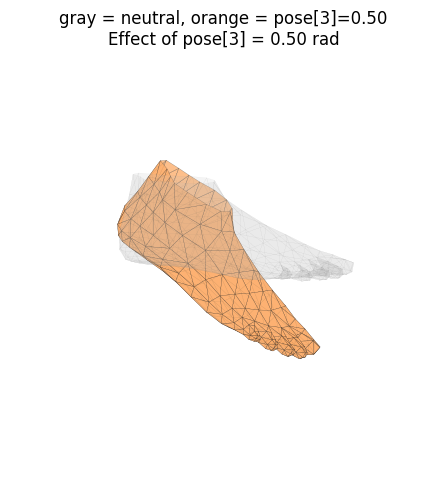

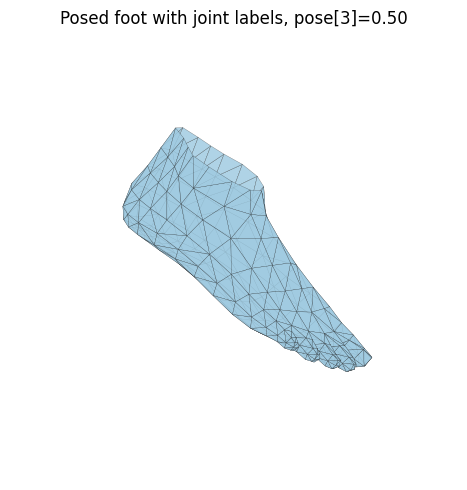

In [10]:
# Change these and re-run. Pose values are in radians.
pose_index = 3
pose_value = 0.5

pose_probe = zeros_pose()
pose_probe[0, pose_index] = pose_value

posed_vertices, posed_joints = run_supr_foot(pose=pose_probe)

print(f"pose[{pose_index}] = {pose_value} radians = {np.degrees(pose_value):.1f} degrees")
print("mean vertex displacement:", np.linalg.norm(posed_vertices - neutral_vertices, axis=1).mean())
print("max  vertex displacement:", np.linalg.norm(posed_vertices - neutral_vertices, axis=1).max())
print("mean joint displacement: ", np.linalg.norm(posed_joints - neutral_joints, axis=1).mean())
print("max  joint displacement: ", np.linalg.norm(posed_joints - neutral_joints, axis=1).max())

plot_compare(
    neutral_vertices,
    posed_vertices,
    title=f"Effect of pose[{pose_index}] = {pose_value:.2f} rad",
    changed_label=f"pose[{pose_index}]={pose_value:.2f}",
)
plot_foot(posed_vertices, posed_joints, title=f"Posed foot with joint labels, pose[{pose_index}]={pose_value:.2f}")


In [11]:
# Pose influence scan: this helps discover which pose parameter moves which part most.
pose_scan_value = 0.5
pose_rows = []
for idx in range(supr_foot.num_pose):
    p = zeros_pose()
    p[0, idx] = pose_scan_value
    v, j = run_supr_foot(pose=p)
    vertex_disp = np.linalg.norm(v - neutral_vertices, axis=1)
    joint_disp = np.linalg.norm(j - neutral_joints, axis=1)
    pose_rows.append((idx, vertex_disp.mean(), vertex_disp.max(), joint_disp.mean(), joint_disp.max()))

print("pose_idx | mean_v_disp | max_v_disp | mean_j_disp | max_j_disp")
print("-" * 68)
for row in sorted(pose_rows, key=lambda r: r[2], reverse=True):
    print(f"{row[0]:8d} | {row[1]:11.5f} | {row[2]:10.5f} | {row[3]:11.5f} | {row[4]:10.5f}")


pose_idx | mean_v_disp | max_v_disp | mean_j_disp | max_j_disp
--------------------------------------------------------------------
       0 |     0.23502 |    0.25949 |     0.22725 |    0.25630
       2 |     0.22906 |    0.24361 |     0.21634 |    0.23949
       1 |     0.06328 |    0.11333 |     0.07591 |    0.10808
       4 |     0.05523 |    0.10735 |     0.07202 |    0.10116
       3 |     0.05615 |    0.10588 |     0.07250 |    0.10148
       7 |     0.01683 |    0.04661 |     0.02496 |    0.04490
       6 |     0.01504 |    0.04499 |     0.02268 |    0.04251
       5 |     0.02109 |    0.03745 |     0.01756 |    0.02785
       8 |     0.00867 |    0.02230 |     0.01145 |    0.02385
      10 |     0.00097 |    0.01834 |     0.00090 |    0.01165
       9 |     0.00085 |    0.01777 |     0.00090 |    0.01166
      16 |     0.00071 |    0.01448 |     0.00076 |    0.00985
      21 |     0.00081 |    0.01429 |     0.00068 |    0.00886
      27 |     0.00073 |    0.01417 |     0.00071

## 5.4 — `trans`: global translation

`trans` does not reshape the foot and does not bend the joints. It simply moves the whole output mesh.

If I add:

```text
trans = [0.10, 0.00, 0.00]
```

every vertex and every joint shifts by +0.10 in x.

This is useful for putting the foot into the same coordinate frame as a shoe, but by itself it does not align orientation or scale.


neutral
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]
translated by [ 0.05  0.02 -0.03]
  raw SUPR min xyz: [-0.11143257 -1.3369797  -0.14568643]
  raw SUPR max xyz: [-0.00844138 -1.2318517   0.12629017]
  raw SUPR size xyz: [0.10299119 0.10512805 0.2719766 ]
  raw SUPR center:  [-0.05993697 -1.2844157  -0.00969813]
expected bbox min shift: [ 0.05  0.02 -0.03]
actual   bbox min shift: [ 0.05        0.01999998 -0.02999999]


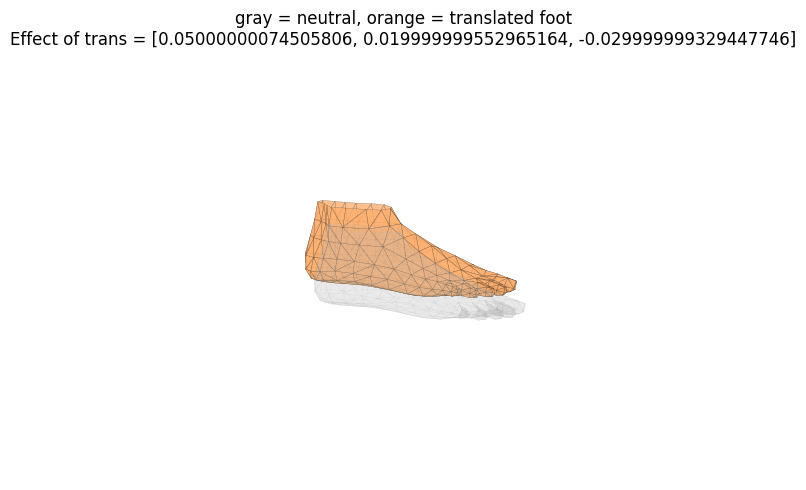

In [12]:
# Change this translation vector and re-run.
trans_vector = np.array([0.05, 0.02, -0.03], dtype=np.float32)
trans_probe = torch.tensor(trans_vector[None], dtype=torch.float32, device="cuda")

translated_vertices, translated_joints = run_supr_foot(trans=trans_probe)

bbox_report(neutral_vertices, "neutral")
bbox_report(translated_vertices, f"translated by {trans_vector}")
print("expected bbox min shift:", trans_vector)
print("actual   bbox min shift:", translated_vertices.min(axis=0) - neutral_vertices.min(axis=0))

plot_compare(
    neutral_vertices,
    translated_vertices,
    title=f"Effect of trans = {trans_vector.tolist()}",
    changed_label="translated foot",
)


## 5.5 — Coordinate system intuition

The raw SUPR-Foot vertices come out as ordinary `x, y, z` coordinates, but the axes do not automatically match how matplotlib displays a 3D object.

For this right-foot model, the practical interpretation is:

```text
raw SUPR x: side-to-side / foot width
raw SUPR y: body vertical direction / foot height
raw SUPR z: heel-to-toe direction / foot length
```

So the plotting helpers above intentionally remap the view:

```text
plot horizontal x <- raw SUPR z   # foot length
plot horizontal y <- raw SUPR x   # foot width
plot vertical z   <- raw SUPR y   # height
```

That is only for visualization. The actual exported OBJ/SDF still use the raw SUPR coordinates unless we explicitly transform them later.


neutral SUPR right foot
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]
Coordinate intuition:
  x: side-to-side body direction
  y: vertical body direction
  z: foot length / front-back direction

Joint positions, useful for debugging pose:
joint 00: x=-0.1629, y=-0.8729, z=-0.0558
joint 01: x=-0.1150, y=-1.3128, z=-0.0572
joint 02: x=-0.1096, y=-1.3331, z= 0.0603
joint 03: x=-0.0712, y=-1.3482, z= 0.1189
joint 04: x=-0.0712, y=-1.3475, z= 0.1425
joint 05: x=-0.1001, y=-1.3454, z= 0.1246
joint 06: x=-0.0981, y=-1.3507, z= 0.1444
joint 07: x=-0.1151, y=-1.3478, z= 0.1148
joint 08: x=-0.1141, y=-1.3507, z= 0.1325
joint 09: x=-0.1411, y=-1.3404, z= 0.1007
joint 10: x=-0.1331, y=-1.3497, z= 0.1169
joint 11: x=-0.1561, y=-1.3461, z= 0.0841
joint 12: x=-0.1450, y=-1.3482, z= 0.1000


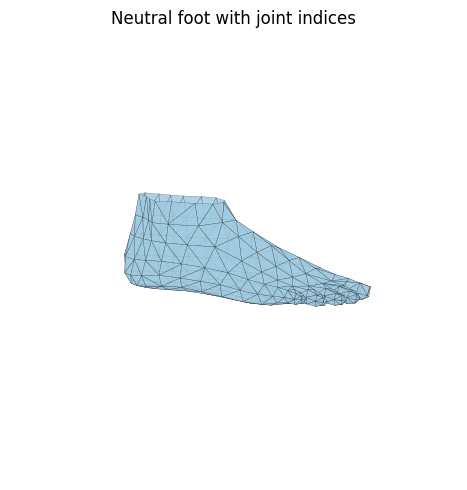

In [13]:
bbox_report(neutral_vertices, "neutral SUPR right foot")
print("Coordinate intuition:")
print("  x: side-to-side body direction")
print("  y: vertical body direction")
print("  z: foot length / front-back direction")
print()
print("Joint positions, useful for debugging pose:")
for idx, p in enumerate(neutral_joints):
    print(f"joint {idx:02d}: x={p[0]: .4f}, y={p[1]: .4f}, z={p[2]: .4f}")

plot_foot(neutral_vertices, neutral_joints, title="Neutral foot with joint indices")


## 5.6 — Mini interactive explorer

This is the easiest place to build intuition.

Use the sliders to change one beta, one pose value, and translation. The camera sliders rotate the foot in a turntable-style view, so I can inspect the foot from the side/front/back without looking at a confusing underside/base view.

If `ipywidgets` is not available in this Jupyter environment, I can still use the manual cells above.


In [14]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    beta_idx_widget = widgets.IntSlider(value=0, min=0, max=num_betas - 1, step=1, description="beta idx")
    beta_val_widget = widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.25, description="beta val")
    pose_idx_widget = widgets.IntSlider(value=3, min=0, max=supr_foot.num_pose - 1, step=1, description="pose idx")
    pose_val_widget = widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05, description="pose val")
    tx_widget = widgets.FloatSlider(value=0.0, min=-0.20, max=0.20, step=0.01, description="trans x")
    ty_widget = widgets.FloatSlider(value=0.0, min=-0.20, max=0.20, step=0.01, description="trans y")
    tz_widget = widgets.FloatSlider(value=0.0, min=-0.20, max=0.20, step=0.01, description="trans z")
    elev_widget = widgets.IntSlider(value=8, min=-5, max=45, step=1, description="elev")
    azim_widget = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azim")
    view_widget = widgets.ToggleButtons(options=["foot", "compare", "turntable"], value="foot", description="view")
    show_joints_widget = widgets.Checkbox(value=False, description="show joints")
    show_axes_widget = widgets.Checkbox(value=False, description="show axes")
    out = widgets.Output()

    def redraw(_=None):
        b = zeros_betas()
        b[0, beta_idx_widget.value] = beta_val_widget.value
        p = zeros_pose()
        p[0, pose_idx_widget.value] = pose_val_widget.value
        t = torch.tensor([[tx_widget.value, ty_widget.value, tz_widget.value]], dtype=torch.float32, device="cuda")
        v, j = run_supr_foot(pose=p, betas=b, trans=t)
        with out:
            clear_output(wait=True)
            print(f"beta[{beta_idx_widget.value}] = {beta_val_widget.value}")
            print(f"pose[{pose_idx_widget.value}] = {pose_val_widget.value} rad ({np.degrees(pose_val_widget.value):.1f} deg)")
            print(f"trans = [{tx_widget.value:.3f}, {ty_widget.value:.3f}, {tz_widget.value:.3f}]")
            bbox_report(v, "current foot")
            if view_widget.value == "turntable":
                plot_turntable(v, title="current SUPR-Foot turntable", elev=elev_widget.value)
            elif view_widget.value == "compare":
                plot_compare(
                    neutral_vertices,
                    v,
                    title="interactive SUPR-Foot explorer",
                    changed_label="current",
                    elev=elev_widget.value,
                    azim=azim_widget.value,
                    show_axes=show_axes_widget.value,
                )
            else:
                plot_foot(
                    v,
                    j,
                    title="interactive SUPR-Foot explorer",
                    elev=elev_widget.value,
                    azim=azim_widget.value,
                    show_axes=show_axes_widget.value,
                    show_joints=show_joints_widget.value,
                    label_joints=show_joints_widget.value,
                )

    controls = widgets.VBox([
        widgets.HBox([beta_idx_widget, beta_val_widget]),
        widgets.HBox([pose_idx_widget, pose_val_widget]),
        widgets.HBox([tx_widget, ty_widget, tz_widget]),
        widgets.HBox([view_widget, elev_widget, azim_widget]),
        widgets.HBox([show_joints_widget, show_axes_widget]),
    ])
    for w in [
        beta_idx_widget,
        beta_val_widget,
        pose_idx_widget,
        pose_val_widget,
        tx_widget,
        ty_widget,
        tz_widget,
        elev_widget,
        azim_widget,
        view_widget,
        show_joints_widget,
        show_axes_widget,
    ]:
        w.observe(redraw, names="value")
    display(controls, out)
    redraw()
except Exception as exc:
    print("Interactive widgets are not available here.")
    print("Use the manual beta/pose/trans cells above instead.")
    print(type(exc).__name__ + ":", exc)


Output()

## 5.7 — Export the current foot as OBJ or PLY

SUPR gives vertices and faces. OBJ/PLY are just file formats we choose for saving that mesh.

For this project, OBJ is already enough because the foot SDF builder reads OBJ. PLY is useful if a viewer prefers it.


wrote /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/supr_explorer/current_foot.obj
wrote /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/supr_explorer/current_foot.ply


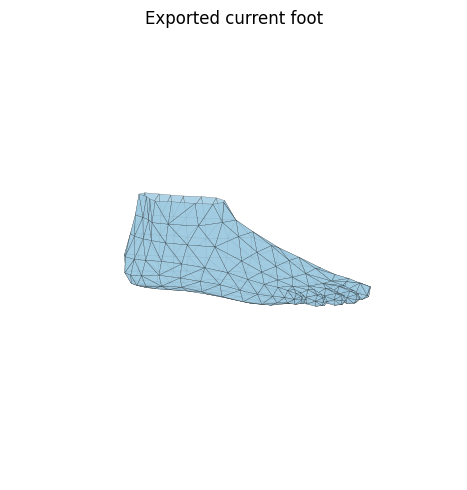

In [15]:
def write_mesh_obj(path, vertices, faces):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    vertices = np.asarray(vertices)
    faces = np.asarray(faces, dtype=np.int64)
    with path.open("w") as f:
        for v in vertices:
            f.write(f"v {v[0]:.8f} {v[1]:.8f} {v[2]:.8f}\n")
        for tri in faces:
            f.write(f"f {tri[0] + 1} {tri[1] + 1} {tri[2] + 1}\n")
    print("wrote", path)

def write_mesh_ply(path, vertices, faces):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    vertices = np.asarray(vertices)
    faces = np.asarray(faces, dtype=np.int64)
    with path.open("w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(vertices)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element face {len(faces)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        for v in vertices:
            f.write(f"{v[0]:.8f} {v[1]:.8f} {v[2]:.8f}\n")
        for tri in faces:
            f.write(f"3 {tri[0]} {tri[1]} {tri[2]}\n")
    print("wrote", path)

# Choose what to export. Change these values and re-run.
export_betas = zeros_betas()
export_pose = zeros_pose()
export_trans = zeros_trans()

export_vertices, export_joints = run_supr_foot(export_pose, export_betas, export_trans)
export_root = Path(repo_root) / "output" / "supr_explorer"
write_mesh_obj(export_root / "current_foot.obj", export_vertices, foot_faces)
write_mesh_ply(export_root / "current_foot.ply", export_vertices, foot_faces)
plot_foot(export_vertices, export_joints, title="Exported current foot")


## 5.8 — Dense mesh vs dense scan

The exported SUPR-Foot mesh looks coarse because the separate right-foot model we downloaded has only `266` vertices and `515` faces.

This is a **parametric template mesh**, not a dense raw foot scan. A dense scan would contain much more surface detail from a real captured foot. That is not present in the current `data/` folder.

What I can do locally is create a **denser mesh** by subdividing the triangles. This makes the mesh smoother to visualize and can be useful for some SDF/debugging workflows, but it does **not** invent new anatomical detail. It is still the same SUPR-Foot shape, just with more triangles.

So:

```text
dense scan       = new measured geometry/details, not available locally right now
subdivided mesh  = same SUPR shape, more triangles, available immediately
```


Original: 266 vertices, 515 faces
Dense:    4151 vertices, 8240 faces
subdivided x2
  raw SUPR min xyz: [-0.16143256 -1.3569797  -0.11568644]
  raw SUPR max xyz: [-0.05844138 -1.2518517   0.15629017]
  raw SUPR size xyz: [0.10299118 0.10512805 0.27197662]
  raw SUPR center:  [-0.10993697 -1.3044157   0.02030187]
wrote /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/supr_explorer/current_foot_subdiv2.obj
wrote /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/supr_explorer/current_foot_subdiv2.ply


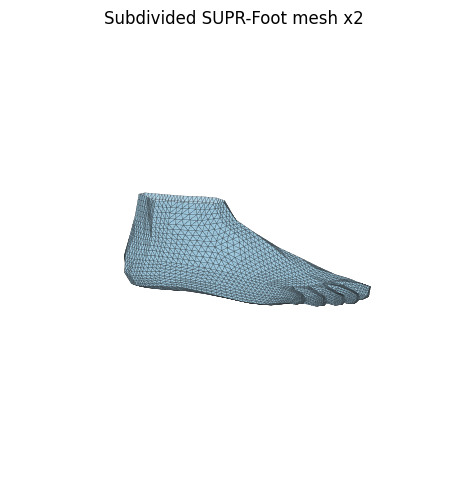

In [16]:
def subdivide_triangles(vertices, faces, iterations=1):
    """Midpoint subdivision. Adds density but does not add new anatomical detail."""
    vertices = np.asarray(vertices, dtype=np.float32)
    faces = np.asarray(faces, dtype=np.int64)

    for _ in range(iterations):
        new_vertices = vertices.tolist()
        midpoint_cache = {}

        def midpoint_index(i, j):
            key = tuple(sorted((int(i), int(j))))
            if key not in midpoint_cache:
                midpoint = ((vertices[key[0]] + vertices[key[1]]) * 0.5).astype(np.float32)
                midpoint_cache[key] = len(new_vertices)
                new_vertices.append(midpoint.tolist())
            return midpoint_cache[key]

        new_faces = []
        for a, b, c in faces:
            ab = midpoint_index(a, b)
            bc = midpoint_index(b, c)
            ca = midpoint_index(c, a)
            new_faces.extend([
                [a, ab, ca],
                [ab, b, bc],
                [ca, bc, c],
                [ab, bc, ca],
            ])

        vertices = np.asarray(new_vertices, dtype=np.float32)
        faces = np.asarray(new_faces, dtype=np.int64)

    return vertices, faces

# Try 1 or 2 first. 3 gets larger but still manageable.
subdivision_iterations = 2

dense_source_vertices = export_vertices if "export_vertices" in globals() else neutral_vertices
dense_vertices, dense_faces = subdivide_triangles(
    dense_source_vertices,
    foot_faces,
    iterations=subdivision_iterations,
)

print("Original:", dense_source_vertices.shape[0], "vertices,", foot_faces.shape[0], "faces")
print("Dense:   ", dense_vertices.shape[0], "vertices,", dense_faces.shape[0], "faces")
bbox_report(dense_vertices, f"subdivided x{subdivision_iterations}")

dense_root = Path(repo_root) / "output" / "supr_explorer"
write_mesh_obj(dense_root / f"current_foot_subdiv{subdivision_iterations}.obj", dense_vertices, dense_faces)
write_mesh_ply(dense_root / f"current_foot_subdiv{subdivision_iterations}.ply", dense_vertices, dense_faces)

# Temporarily swap faces only for plotting this denser mesh.
old_foot_faces = foot_faces
foot_faces = dense_faces
plot_foot(dense_vertices, title=f"Subdivided SUPR-Foot mesh x{subdivision_iterations}")
foot_faces = old_foot_faces


## 6 — Forward pass: neutral posed foot

This mirrors `demo/load_torch.py`: zero pose, zero shape, zero translation.


In [17]:
poses = torch.cuda.FloatTensor(np.zeros((batch_size, supr_foot.num_pose), dtype=np.float32))
betas = torch.cuda.FloatTensor(np.zeros((batch_size, num_betas), dtype=np.float32))
trans = torch.cuda.FloatTensor(np.zeros((batch_size, 3), dtype=np.float32))

with torch.no_grad():
    verts = supr_foot.forward(poses, betas, trans)

print("verts:", verts.shape)
print("faces:", supr_foot.f.shape)
print("bounds min:", verts[0].min(dim=0).values.detach().cpu().numpy())
print("bounds max:", verts[0].max(dim=0).values.detach().cpu().numpy())
print("joints:", verts.J_transformed.shape)


verts: torch.Size([1, 266, 3])
faces: (515, 3)
bounds min: [-0.16143256 -1.3569797  -0.11568644]
bounds max: [-0.05844138 -1.2518517   0.15629017]
joints: torch.Size([1, 13, 3])


## 7 — Forward pass: change shape coefficients

This is where shoe-size experiments eventually start. Keep values small while debugging; large beta values can produce unrealistic shapes.


In [18]:
betas_shape = torch.zeros((batch_size, num_betas), dtype=torch.float32, device="cuda")
betas_shape[0, 0] = 1.0
betas_shape[0, 1] = -0.5

with torch.no_grad():
    verts_shape = supr_foot.forward(poses, betas_shape, trans)

delta = verts_shape[0] - verts[0]
print("shape-changed verts:", verts_shape.shape)
print("delta norm min/max/mean:", delta.norm(dim=-1).min().item(), delta.norm(dim=-1).max().item(), delta.norm(dim=-1).mean().item())


shape-changed verts: torch.Size([1, 266, 3])
delta norm min/max/mean: 0.0005365125252865255 0.007674834690988064 0.004001077730208635


## 8 — Forward pass: change pose coefficients

SUPR-Foot has 39 pose values for 13 joints. The exact semantic mapping needs care, so this cell is only a controlled probe.


In [19]:
pose_probe = torch.zeros((batch_size, supr_foot.num_pose), dtype=torch.float32, device="cuda")
pose_probe[0, 3] = 0.25

with torch.no_grad():
    verts_pose = supr_foot.forward(pose_probe, betas, trans)

delta_pose = verts_pose[0] - verts[0]
print("pose-changed verts:", verts_pose.shape)
print("delta norm min/max/mean:", delta_pose.norm(dim=-1).min().item(), delta_pose.norm(dim=-1).max().item(), delta_pose.norm(dim=-1).mean().item())


pose-changed verts: torch.Size([1, 266, 3])
delta norm min/max/mean: 0.0018064964096993208 0.053387101739645004 0.028321854770183563


## 9 — Save mesh OBJ

OBJ export is tiny: write vertices and faces. Faces are converted from zero-based Python indices to one-based OBJ indices.


In [20]:
def save_obj(path, vertices, faces):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    vertices = np.asarray(vertices)
    faces = np.asarray(faces, dtype=np.int64)
    with path.open("w") as f:
        for v in vertices:
            f.write(f"v {v[0]:.8f} {v[1]:.8f} {v[2]:.8f}\n")
        for tri in faces:
            a, b, c = tri + 1
            f.write(f"f {a} {b} {c}\n")
    return path

export_dir = Path(repo_root) / "output" / "debug_playground"
obj_path = save_obj(export_dir / "supr_male_right_foot_neutral.obj", verts[0].detach().cpu().numpy(), supr_foot.f)
print("Saved:", obj_path)


Saved: /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/debug_playground/supr_male_right_foot_neutral.obj


## 10 — Scratch cell

Use this for ad-hoc inspection: joint locations, beta sweeps, pose sweeps, mesh export variants, or future SDF conversion checks.


In [21]:
print("Kinematic tree:")
print(supr_foot.kintree_table.detach().cpu().numpy())

print("Joint positions:")
print(verts.J_transformed[0].detach().cpu().numpy())


Kinematic tree:
[[4294967295          0          1          2          3          2
           5          2          7          2          9          2
          11]
 [         0          1          2          3          4          5
           6          7          8          9         10         11
          12]]
Joint positions:
[[-0.16289997 -0.87293243 -0.05576801]
 [-0.11504173 -1.312849   -0.05719805]
 [-0.10964206 -1.3330551   0.06028048]
 [-0.07120734 -1.3481674   0.11894491]
 [-0.07123808 -1.347504    0.14249831]
 [-0.10009586 -1.345377    0.12455817]
 [-0.09811606 -1.3506801   0.14436553]
 [-0.11514269 -1.3478479   0.11477385]
 [-0.11405104 -1.35068     0.13246001]
 [-0.14111042 -1.3403937   0.10068285]
 [-0.13314171 -1.3497158   0.11690466]
 [-0.15605201 -1.3460782   0.0841423 ]
 [-0.14500475 -1.3481772   0.10003686]]
